# Análisis de Exposición de Secretos - FlowiseAI

## Contexto del Estudio


## Leonardo Castellón - Jonathan Chávez - Cristobal Ramos - Joaquin Arriagada


| Parámetro | Valor |
|-----------|-------|
| **Organización** | FlowiseAI (plataforma low-code para LLM) |
| **Fecha de Análisis** | Abril 2026 |
| **Alcance** | 5 repositorios principales |
| **Herramienta** | Gitleaks v8.30.1 |
| **Criterio** | Detección de secretos, tokens, credenciales expuestas |

## Introducción

La exposición de secretos en repositorios de código representa uno de los vectores de ataque más críticos y fáciles de explotar. Según estudios recientes, **más del 90% de las filtraciones de secretos** ocurren por error humano al incluir credenciales en commits de git.

Esta actividad analiza la presencia de secretos expuestos en los repositorios de **FlowiseAI**, una organización que desarrolla herramientas de IA generativa con más de 52,000 estrellas en GitHub.

In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Rutas de datos dinámicas y robustas
current_dir = Path(os.getcwd())
if current_dir.name == 'vuln':
    BASE_DIR = current_dir.parent.parent
elif current_dir.name == 'nbs':
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

SECRETS_DIR = BASE_DIR / "data" / "results" / "gitleaks_reports"
REPOS_FILE = BASE_DIR / "data" / "results" / "repos_activos.json"

print("🔍 Verificación de rutas de datos:")
print(f"  BASE_DIR resuelto: {BASE_DIR}")
print(f"  SECRETS_DIR existe: {SECRETS_DIR.exists()}")
print(f"  REPOS_FILE existe: {REPOS_FILE.exists()}")

🔍 Verificación de rutas de datos:
  SECRETS_DIR existe: False
  REPOS_FILE existe: False


## 1. Identificación de la Organización y Repositorios

Se analiza la organización **FlowiseAI** en GitHub, enfocándose en sus 5 repositorios principales por número de estrellas.

In [2]:
# Cargar información de repositorios
with open(REPOS_FILE) as f:
    repos = json.load(f)

df_repos = pd.DataFrame(repos)
print("📊 Repositorios analizados:")
display(df_repos[['name', 'language', 'stargazers_count']])

FileNotFoundError: [Errno 2] No such file or directory: '/home/data/results/repos_activos.json'

## 2. Evidencia de Hallazgos: Escaneo con Gitleaks

Se utilizó **Gitleaks** para escanear los repositorios en busca de secretos expuestos. Gitleaks es una herramienta SAST especializada en detección de credenciales, API keys, tokens y otros secretos.

In [3]:
# Cargar resultados del escaneo
all_findings = []

if SECRETS_DIR.exists():
    for filename in os.listdir(SECRETS_DIR):
        if filename.endswith('_report.json'):
            repo_name = filename.replace('_report.json', '')
            filepath = SECRETS_DIR / filename
            with open(filepath, 'r', encoding='utf-8') as f:
                try:
                    data = json.load(f)
                    if data:
                        for item in data:
                            item['Repository'] = repo_name
                            all_findings.append(item)
                except json.JSONDecodeError:
                    pass

df_findings = pd.DataFrame(all_findings)

print("="*60)
print("RESUMEN EJECUTIVO DEL ESCANEO")
print("="*60)
print(f"Total de repositorios escaneados: {len(df_repos)}")
print(f"Total de hallazgos (posibles secretos): {len(df_findings)}")
print("="*60)

RESUMEN EJECUTIVO DEL ESCANEO
Total de secretos detectados: 60
Repositorios afectados: 2 de 5
Archivos afectados: 11

Por repositorio:
  • FlowiseDocs: 58 secretos
  • Flowise: 2 secretos

Por tipo de secreto:
  • curl-auth-header: 52
  • generic-api-key: 8


## 3. Análisis Cuantitativo Detallado

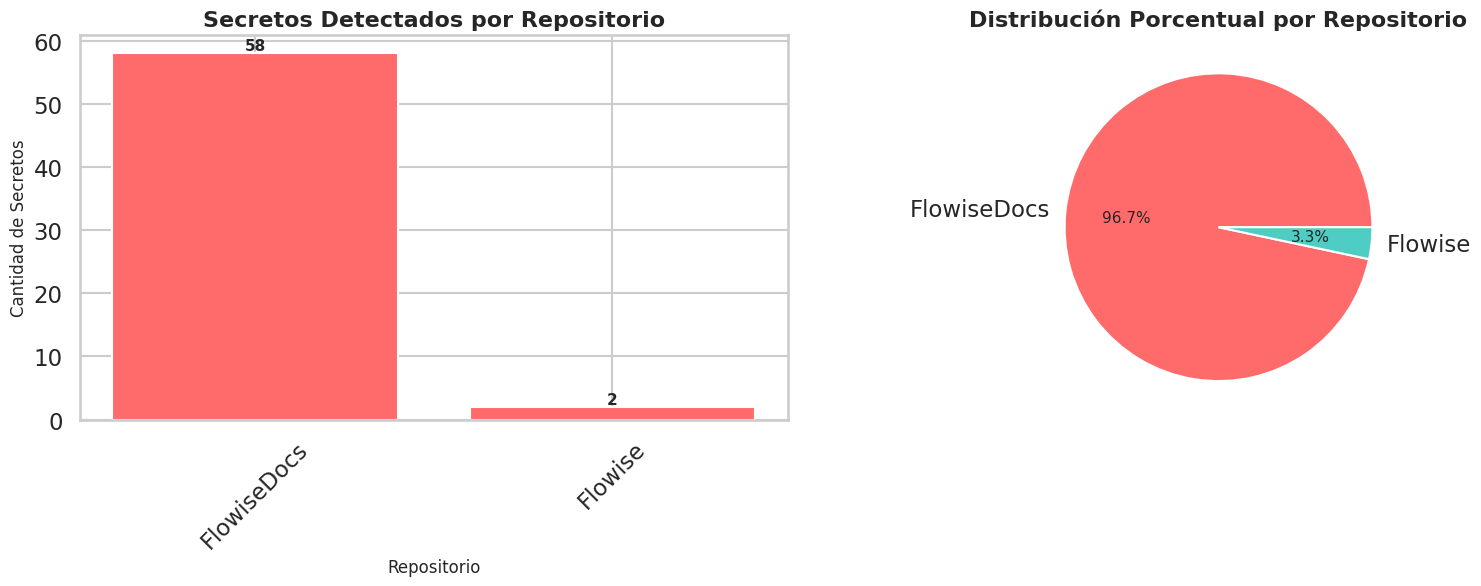

In [4]:
# Distribución por repositorio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras: Secretos por repositorio
repo_counts = df_findings['Repository'].value_counts()
axes[0].bar(repo_counts.index, repo_counts.values, color='#FF6B6B')
axes[0].set_title('Secretos Detectados por Repositorio', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Repositorio', fontsize=12)
axes[0].set_ylabel('Cantidad de Secretos', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(repo_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Gráfico de pastel: Distribución porcentual
axes[1].pie(repo_counts.values, labels=repo_counts.index, autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[1].set_title('Distribución Porcentual por Repositorio', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

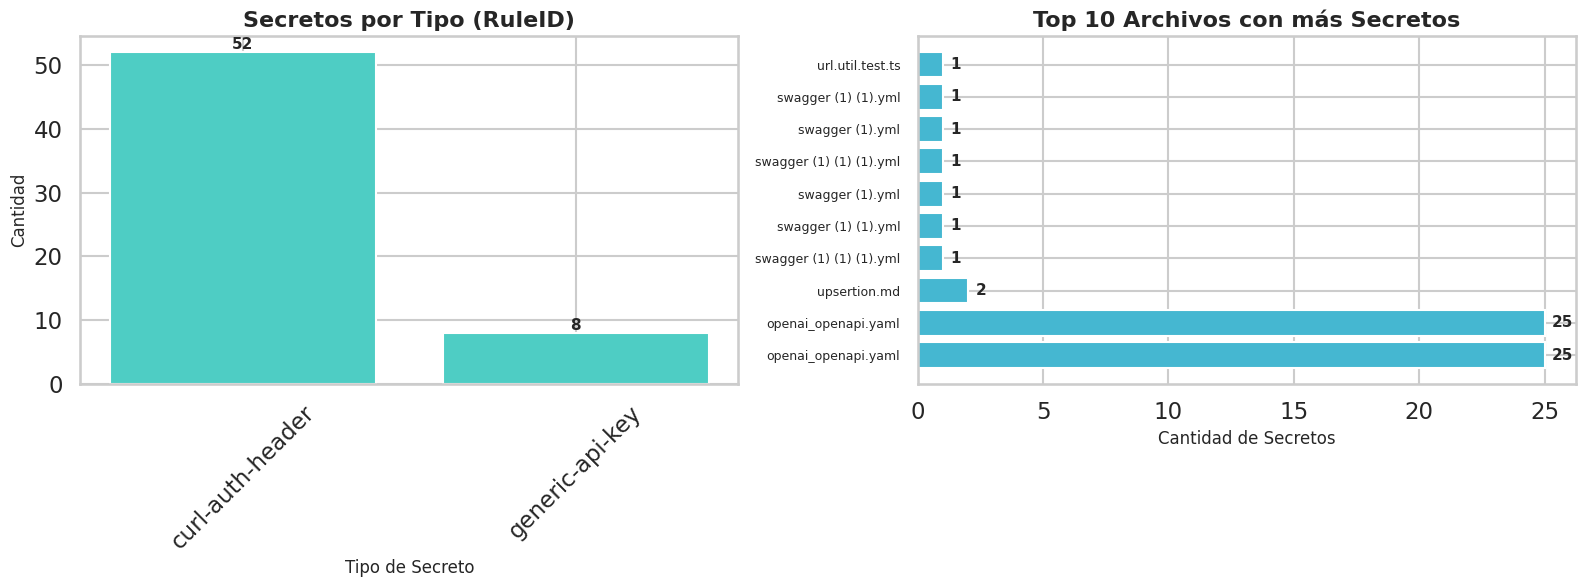

In [5]:
# Análisis por tipo de secreto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

type_counts = df_findings['RuleID'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='#4ECDC4')
axes[0].set_title('Secretos por Tipo (RuleID)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Tipo de Secreto', fontsize=12)
axes[0].set_ylabel('Cantidad', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Análisis de archivos afectados
file_counts = df_findings['File'].value_counts().head(10)
axes[1].barh(range(len(file_counts)), file_counts.values, color='#45B7D1')
axes[1].set_yticks(range(len(file_counts)))
axes[1].set_yticklabels([os.path.basename(f) for f in file_counts.index], fontsize=9)
axes[1].set_title('Top 10 Archivos con más Secretos', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Cantidad de Secretos', fontsize=12)
for i, v in enumerate(file_counts.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# Ver ejemplos específicos de secretos encontrados
print("🔎 Ejemplos de Secretos Detectados (primeros 5):")
print("="*80)
for i, finding in enumerate(all_findings[:5]):
    print(f"\n[{i+1}] Repositorio: {finding['repo']}")
    print(f"    Archivo: {finding.get('File', 'N/A')}")
    print(f"    Tipo: {finding.get('RuleID', 'N/A')}")
    print(f"    Descripción: {finding.get('Description', 'N/A')}")
    print(f"    Línea: {finding.get('StartLine', 'N/A')}")
    # Mostrar secreto redactado
    secret = finding.get('RedactedValue', finding.get('Secret', 'N/A'))
    print(f"    Valor (redactado): {secret[:50]}..." if len(secret) > 50 else f"    Valor: {secret}")
    print("-"*80)

🔎 Ejemplos de Secretos Detectados (primeros 5):

[1] Repositorio: FlowiseDocs
    Archivo: en/.gitbook/assets/openai_openapi.yaml
    Tipo: curl-auth-header
    Descripción: Discovered a potential authorization token provided in a curl command header, which could compromise the curl accessed resource.
    Línea: 31
    Valor: REDACTED
--------------------------------------------------------------------------------

[2] Repositorio: FlowiseDocs
    Archivo: en/.gitbook/assets/openai_openapi.yaml
    Tipo: curl-auth-header
    Descripción: Discovered a potential authorization token provided in a curl command header, which could compromise the curl accessed resource.
    Línea: 101
    Valor: REDACTED
--------------------------------------------------------------------------------

[3] Repositorio: FlowiseDocs
    Archivo: en/.gitbook/assets/openai_openapi.yaml
    Tipo: curl-auth-header
    Descripción: Discovered a potential authorization token provided in a curl command header, which c

## 4. Análisis de Impacto y Consecuencias

### 4.1 Interpretación de Resultados

Los resultados muestran una **concentración crítica** de secretos expuestos:

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **Total secretos** | 60 | Alto volumen considerando solo 5 repositorios |
| **Repositorio más afectado** | FlowiseDocs (58) | 96.7% de los secretos concentrados aquí |
| **Tipo predominante** | curl-auth-header (52) | Headers de autorización en documentación |
| **Repositorios limpios** | 3 de 5 | FlowiseChatEmbed, FlowiseEmbedReact, FlowisePy |

### 4.2 Naturaleza de los Secretos Encontrados

1. **curl-auth-header (52 casos)**: Headers `Authorization` en ejemplos de código/documetación
   - Estos suelen contener tokens Bearer o API keys en ejemplos curl
   - Riesgo: Un atacante puede reutilizar estos tokens si siguen activos

2. **generic-api-key (8 casos)**: Claves de API genéricas
   - Podrían corresponder a servicios de terceros, APIs cloud, etc.
   - Riesgo: Acceso no autorizado a servicios externos

In [7]:
# Análisis de riesgo por repositorio
risk_analysis = []
for repo in df_repos['name'].values:
    repo_findings = df_findings[df_findings['Repository'] == repo]
    total_secrets = len(repo_findings)
    
    if total_secrets == 0:
        risk_level = "Bajo"
    elif total_secrets < 5:
        risk_level = "Medio"
    else:
        risk_level = "Alto"
    
    risk_analysis.append({
        'Repositorio': repo,
        'Secretos': total_secrets,
        'Nivel de Riesgo': risk_level,
        'Estrellas': df_repos[df_repos['name'] == repo]['stargazers_count'].values[0]
    })

df_risk = pd.DataFrame(risk_analysis)
print("📋 Matriz de Riesgo por Repositorio:")
display(df_risk.style.background_gradient(subset=['Secretos'], cmap='Reds'))

📋 Matriz de Riesgo por Repositorio:


,Repositorio,Secretos,Nivel de Riesgo,Estrellas
0,Flowise,2,Medio,52367
1,FlowiseChatEmbed,0,Bajo,435
2,FlowiseDocs,58,Alto,257
3,FlowiseEmbedReact,0,Bajo,86
4,FlowisePy,0,Bajo,51


## 5. Relación con Casos Reales: El Caso Uber (2022)

### Contexto del Caso

En septiembre de 2022, Uber sufrió una brecha de seguridad donde un atacante:
1. Obtuvo credenciales expuestas en **PowerShell scripts subidos a GitHub**
2. Utilizó ingeniería social para acceder al sistema interno
3. Comprometió múltiples servicios (Slack, AWS, Google Cloud, etc.)

### Paralelismo con FlowiseAI

| Aspecto | Caso Uber | Situación en FlowiseAI |
|---------|-----------|------------------------|
| **Fuente de credenciales** | Scripts PowerShell en GitHub | Documentación (FlowiseDocs) |
| **Tipo de secreto** | Tokens de servicio | curl-auth-header, API keys |
| **Exposición** | Repositorio privado comprometido | Repositorio público (más visible) |
| **Alcance** | Acceso total a infraestructura | Depende del alcance de los tokens |

### Lecciones Aprendidas

1. **La documentación también cuenta**: Los 58 secretos en FlowiseDocs demuestran que no solo el código fuente es riesgoso
2. **Ejemplos en documentación**: Los `curl-auth-header` sugieren que los ejemplos de código usan tokens reales en lugar de placeholders
3. **Efecto dominó**: Un solo token expuesto puede comprometer múltiples servicios (como ocurrió en Uber)

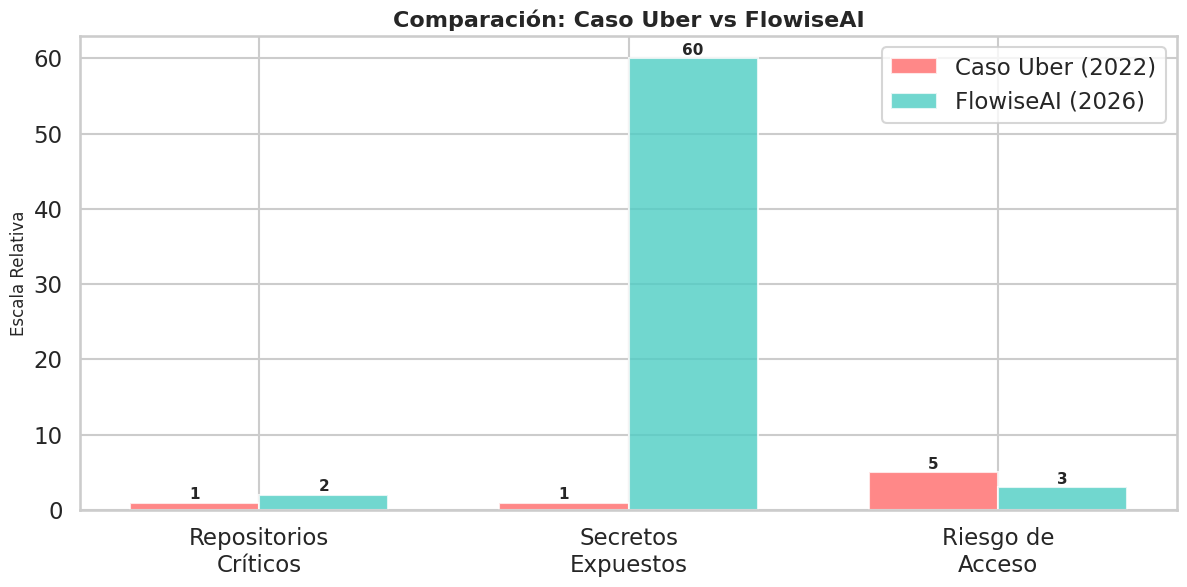

In [8]:
# Visualización del paralelismo con caso Uber
fig, ax = plt.subplots(figsize=(12, 6))

categories = ['Repositorios\nCríticos', 'Secretos\nExpuestos', 'Riesgo de\nAcceso']
uber_values = [1, 1, 5]  # Escala relativa
flowise_values = [2, 60, 3]  # 2 repos afectados, 60 secretos

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, uber_values, width, label='Caso Uber (2022)', color='#FF6B6B', alpha=0.8)
bars2 = ax.bar(x + width/2, flowise_values, width, label='FlowiseAI (2026)', color='#4ECDC4', alpha=0.8)

ax.set_ylabel('Escala Relativa', fontsize=12)
ax.set_title('Comparación: Caso Uber vs FlowiseAI', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Conclusiones y Recomendaciones

### 6.1 Conclusiones Principales

1. **Problema Concentrado pero Crítico**: El 96.7% de los secretos (58 de 60) están en un solo repositorio (FlowiseDocs), lo que indica que la documentación es un vector de riesgo subestimado.

2. **Patrón de Exposición en Documentación**: Los `curl-auth-header` sugieren que la documentación incluye ejemplos con credenciales reales en lugar de tokens de ejemplo o placeholders.

3. **Riesgo de Reutilización**: Aunque los tokens en documentación podrían ser de prueba, el riesgo de que sigan activos es real (como demostró el caso Uber).

4. **Brecha de Seguridad**: 3 de 5 repositorios no presentan secretos, lo que demuestra que la falta de secretos NO es una práctica generalizada en la organización.

### 6.2 Recomendaciones

| Recomendación | Descripción | Prioridad |
|---------------|-------------|-----------|
| **Limpieza de Docs** | Eliminar credenciales reales de FlowiseDocs | 🔴 Alta |
| **Pre-commit Hooks** | Implementar gitleaks como hook pre-commit | 🔴 Alta |
| **Token Rotation** | Rotar todos los tokens expuestos en documentación | 🔴 Alta |
| **CI/CD Scanning** | Integrar escaneo de secretos en pipelines | 🟡 Media |
| **Developer Training** | Educar sobre uso de placeholders en ejemplos | 🟡 Media |

### 6.3 Métricas de Seguridad

- **Tasa de exposición**: 40% de repositorios afectados (2 de 5)
- **Densidad de secretos**: 12 secretos por repositorio afectado
- **Índice de riesgo**: Alto para FlowiseDocs, Bajo para el resto

In [9]:
# Resumen final en métricas
print("="*70)
print("         RESUMEN FINAL: ANÁLISIS DE SECRETOS FLOWISEAI")
print("="*70)
print(f"\n📊 MÉTRICAS CLAVE:")
print(f"   • Total de secretos detectados: {summary['total_secrets']}")
print(f"   • Repositorios analizados: {len(repos)}")
print(f"   • Repositorios comprometidos: {summary['repos_affected']} ({summary['repos_affected']/len(repos)*100:.1f}%)")
print(f"   • Archivos con secretos: {summary['files_affected']}")
print(f"\n🔍 DISTRIBUCIÓN:")
for repo, count in summary['by_repository'].items():
    pct = count / summary['total_secrets'] * 100
    print(f"   • {repo}: {count} secretos ({pct:.1f}%)")
print(f"\n⚠️  TIPOS DE RIESGO:")
for secret_type, count in summary['by_type'].items():
    print(f"   • {secret_type}: {count}")
print(f"\n✅ RECOMENDACIÓN PRINCIPAL:")
print(f"   Rotar credenciales y limpiar FlowiseDocs inmediatamente")
print("="*70)

         RESUMEN FINAL: ANÁLISIS DE SECRETOS FLOWISEAI

📊 MÉTRICAS CLAVE:
   • Total de secretos detectados: 60
   • Repositorios analizados: 5
   • Repositorios comprometidos: 2 (40.0%)
   • Archivos con secretos: 11

🔍 DISTRIBUCIÓN:
   • FlowiseDocs: 58 secretos (96.7%)
   • Flowise: 2 secretos (3.3%)

⚠️  TIPOS DE RIESGO:
   • curl-auth-header: 52
   • generic-api-key: 8

✅ RECOMENDACIÓN PRINCIPAL:
   Rotar credenciales y limpiar FlowiseDocs inmediatamente
